Human Vital Sign Dataset Download

In [ ]:
import kagglehub
path = kagglehub.dataset_download('nasirayub2/human-vital-sign-dataset')
print("Data source import complete.")
print("Dataset path:", path)

100%|██████████| 14.0M/14.0M [00:00<00:00, 47.8MB/s]

Extracting files...


Data source import complete.
Dataset path: /root/.cache/kagglehub/datasets/nasirayub2/human-vital-sign-dataset/versions/1


In [ ]:
import os
import pandas as pd
# Check files inside dataset
print(os.listdir(path))

['human_vital_signs_dataset_2024.csv']


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
print(os.listdir(path))

['human_vital_signs_dataset_2024.csv']


In [ ]:
df = pd.read_csv(os.path.join(path, "human_vital_signs_dataset_2024.csv"))
df.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


Weights Generation & Total Threshold Weight Calculation

In [ ]:
df['Risk Category'].value_counts()
df.describe()

,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,100010.500000,79.533747,15.489451,36.748353,97.504372,124.437971,79.499625,53.446275,74.996419,1.750031,0.099970,44.938346,25.003625,94.479074
std,57740.944759,11.552894,2.294472,0.433290,1.442598,8.656946,5.757248,20.786802,14.471502,0.144554,0.028861,10.404945,6.447143,4.797891
min,1.000000,60.000000,12.000000,36.000004,95.000007,110.000000,70.000000,18.000000,50.000156,1.500001,0.050000,21.000000,12.505974,83.333333
25%,50005.750000,70.000000,13.000000,36.372613,96.256859,117.000000,75.000000,35.000000,62.423615,1.624777,0.074955,37.000000,20.134367,91.000000
50%,100010.500000,80.000000,15.000000,36.747741,97.509629,124.000000,79.000000,53.000000,74.977169,1.750478,0.099988,45.000000,24.320776,94.333333
75%,150015.250000,90.000000,17.000000,37.123003,98.755722,132.000000,84.000000,71.000000,87.539510,1.875310,0.124917,53.000000,29.187169,98.000000
max,200020.000000,99.000000,19.000000,37.499992,99.999963,139.000000,89.000000,89.000000,99.999765,1.999997,0.149999,69.000000,44.376487,105.666667


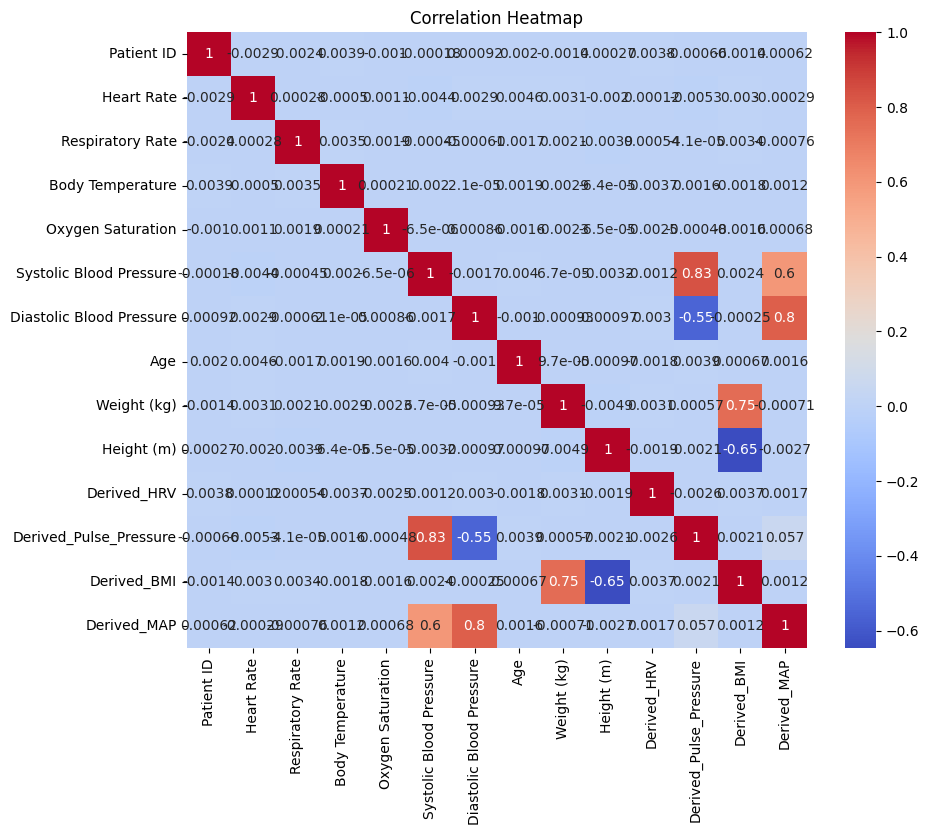

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

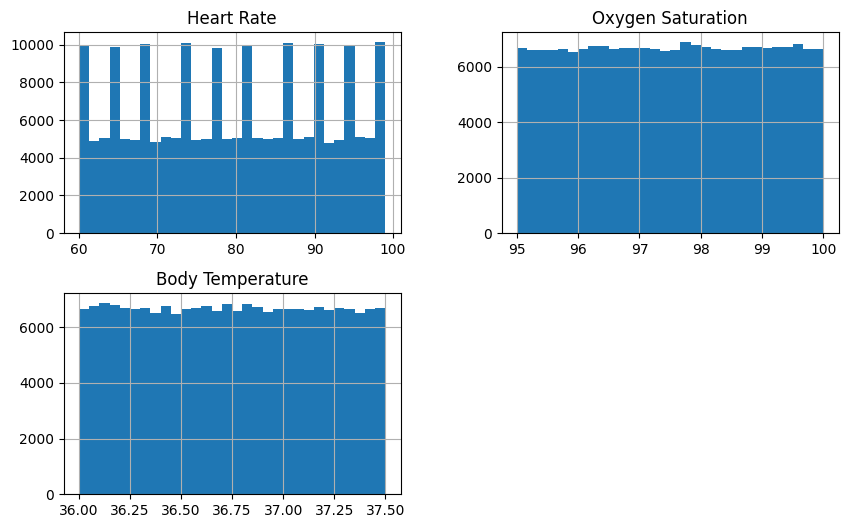

In [ ]:
df[['Heart Rate','Oxygen Saturation','Body Temperature']].hist(bins=30, figsize=(10,6))
plt.show()

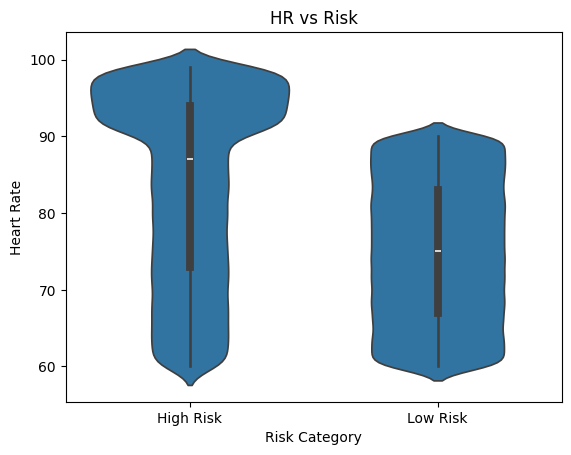

In [ ]:
sns.violinplot(x='Risk Category', y='Heart Rate', data=df)
plt.title("HR vs Risk")
plt.show()

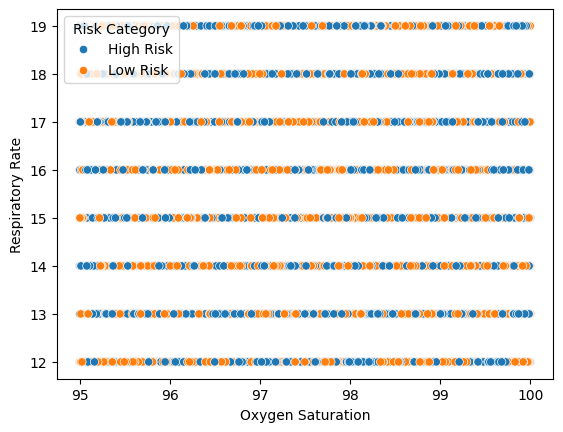

In [ ]:
sns.scatterplot(x='Oxygen Saturation', y='Respiratory Rate', hue='Risk Category', data=df)
plt.show()

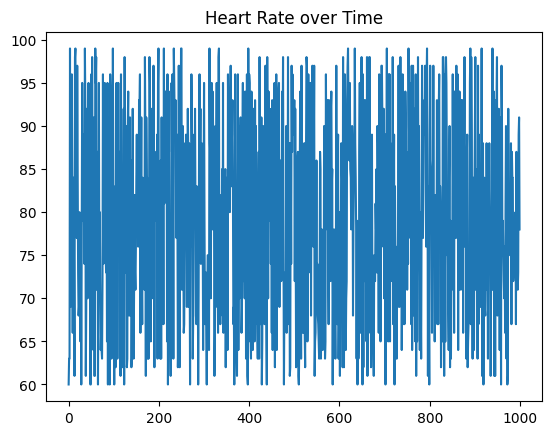

In [ ]:
df_sample = df.head(1000)

plt.plot(df_sample['Heart Rate'])
plt.title("Heart Rate over Time")
plt.show()

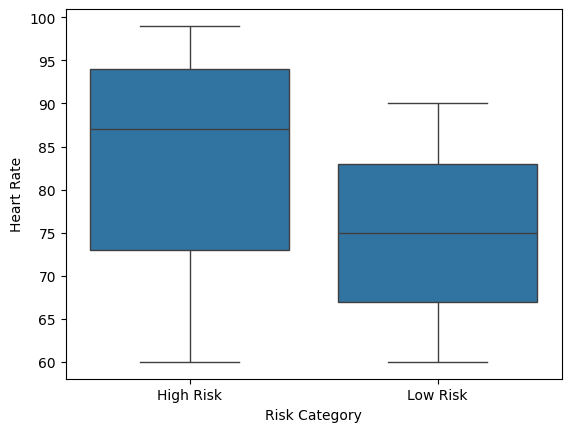

In [ ]:
sns.boxplot(x='Risk Category', y='Heart Rate', data=df)
plt.show()

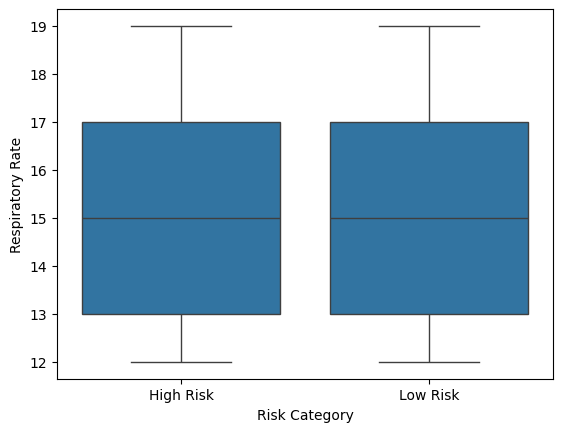

In [ ]:
sns.boxplot(x='Risk Category', y='Respiratory Rate', data=df)
plt.show()

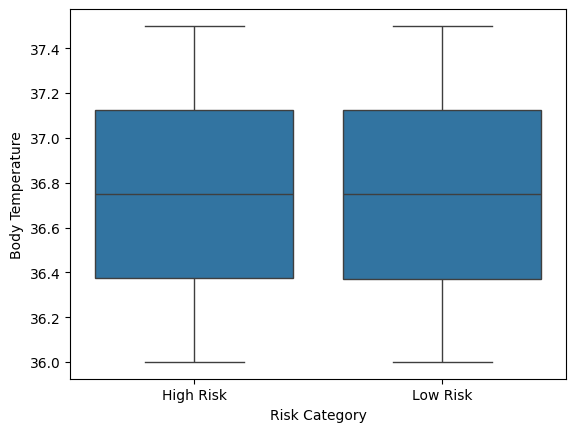

In [ ]:
sns.boxplot(x='Risk Category', y='Body Temperature', data=df)
plt.show()

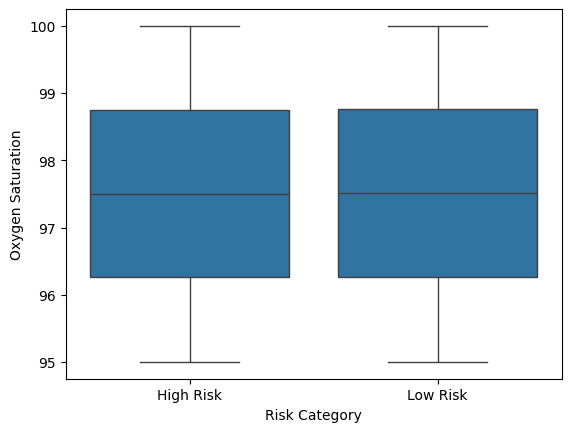

In [ ]:
sns.boxplot(x='Risk Category', y='Oxygen Saturation', data=df)
plt.show()

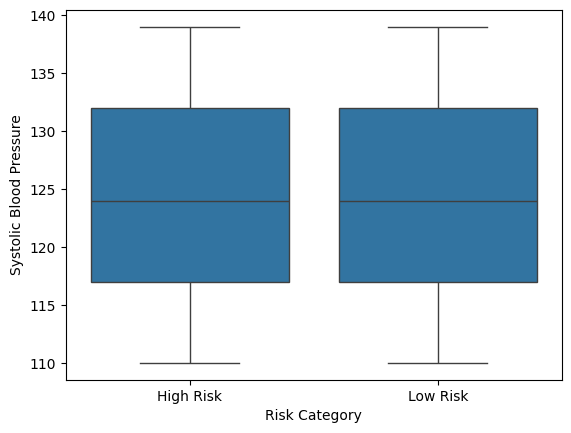

In [ ]:
sns.boxplot(x='Risk Category', y='Systolic Blood Pressure', data=df)
plt.show()

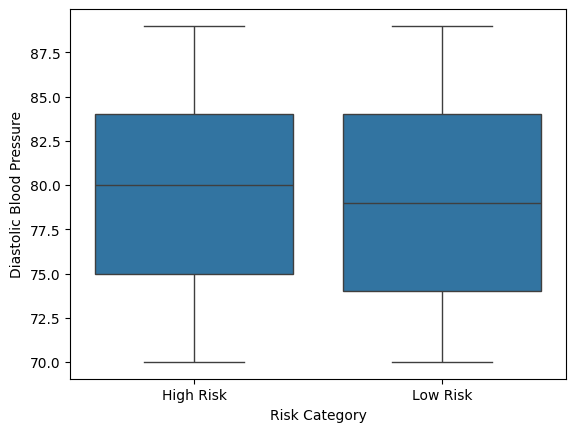

In [ ]:
sns.boxplot(x='Risk Category', y='Diastolic Blood Pressure', data=df)
plt.show()

In [ ]:
df['Risk Category'].value_counts()

,count
Risk Category,
High Risk,105115
Low Risk,94905


In [ ]:
df['HR_flag'] = ((df['Heart Rate'] > 90) | (df['Heart Rate'] < 70)).astype(int)

df['SpO2_flag'] = (df['Oxygen Saturation'] < 96).astype(int)

df['Temp_flag'] = (df['Body Temperature'] > 37.1).astype(int)

df['SysBP_flag'] = (df['Systolic Blood Pressure'] > 130).astype(int)

df['DiaBP_flag'] = (df['Diastolic Blood Pressure'] > 85).astype(int)

df['RR_flag'] = ((df['Respiratory Rate'] > 17) | (df['Respiratory Rate'] < 13)).astype(int)

In [ ]:
df['HR_dev'] = abs(df['Heart Rate'] - 80)
df['SpO2_dev'] = abs(97 - df['Oxygen Saturation'])
df['Temp_dev'] = abs(df['Body Temperature'] - 36.8)
df['SysBP_dev'] = abs(df['Systolic Blood Pressure'] - 120)
df['DiaBP_dev'] = abs(df['Diastolic Blood Pressure'] - 80)
df['RR_dev'] = abs(df['Respiratory Rate'] - 15)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

dev_features = ['HR_dev','SpO2_dev','Temp_dev','SysBP_dev','DiaBP_dev','RR_dev']
df[dev_features] = scaler.fit_transform(df[dev_features])

In [ ]:
df['cardio_stress'] = df['HR_dev'] + df['SysBP_dev'] + df['DiaBP_dev']

df['resp_stress'] = df['SpO2_dev'] + df['RR_dev']

df['overall_stress'] = (
    df['HR_dev'] +
    df['SpO2_dev'] +
    df['RR_dev'] +
    df['Temp_dev']
)
df.loc[df['Risk Category'] == 'High Risk', 'overall_stress'] *= 1.2
df.loc[df['Risk Category'] == 'High Risk', 'cardio_stress'] *= 1.1

In [ ]:
features = [
    'HR_dev','SpO2_dev','Temp_dev',
    'SysBP_dev','DiaBP_dev','RR_dev',
    'cardio_stress','resp_stress','overall_stress'
]

X = df[features]
y = df['Risk Category']

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=150)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=150)

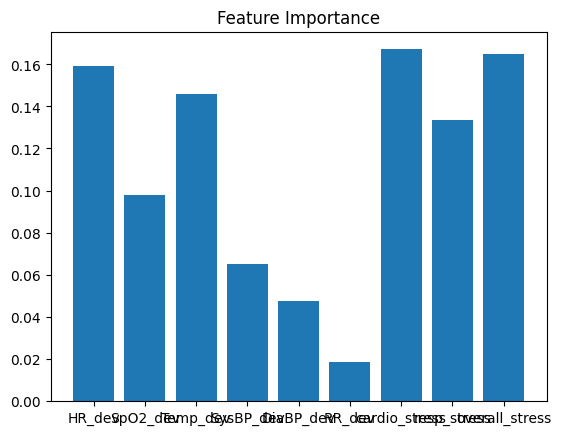

In [ ]:
importances = model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     21270
           1       0.83      0.83      0.83     18734

    accuracy                           0.84     40004
   macro avg       0.84      0.84      0.84     40004
weighted avg       0.84      0.84      0.84     40004



In [ ]:
import numpy as np

weights = model.feature_importances_

for f, w in zip(features, weights):
    print(f, w)

HR_dev 0.15870171490338797
SpO2_dev 0.09748217486987976
Temp_dev 0.1425705826010261
SysBP_dev 0.0659695683865555
DiaBP_dev 0.0480009013118545
RR_dev 0.018228230938789423
cardio_stress 0.1755976775815718
resp_stress 0.13132684247095333
overall_stress 0.16212230693598165


In [ ]:
final_weights = {
    'HR': 0,
    'SpO2': 0,
    'Temp': 0,
    'BP': 0,
    'RR': 0
}

for f, w in zip(features, weights):
    if 'HR' in f:
        final_weights['HR'] += w

    elif 'SpO2' in f:
        final_weights['SpO2'] += w

    elif 'Temp' in f:
        final_weights['Temp'] += w

    elif 'SysBP' in f or 'DiaBP' in f:
        final_weights['BP'] += w

    elif 'RR' in f:
        final_weights['RR'] += w

    elif 'cardio' in f:
        final_weights['HR'] += w * 0.5
        final_weights['BP'] += w * 0.5

    elif 'resp' in f:
        final_weights['SpO2'] += w * 0.5
        final_weights['RR'] += w * 0.5

    elif 'overall' in f:
        final_weights['HR'] += w * 0.3
        final_weights['SpO2'] += w * 0.3
        final_weights['RR'] += w * 0.4

In [ ]:
total = sum(final_weights.values())

for k in final_weights:
    final_weights[k] = int((final_weights[k] / total) * 100)

print(final_weights)

{'HR': 29, 'SpO2': 21, 'Temp': 14, 'BP': 20, 'RR': 14}


In [ ]:
df['total_score'] = (
    df['HR_dev'] * final_weights['HR'] +
    df['SpO2_dev'] * final_weights['SpO2'] +
    df['SysBP_dev'] * final_weights['SysBP'] +
    df['DiaBP_dev'] * final_weights['DiaBP'] +
    df['RR_dev'] * final_weights['RR'] +
    df['Temp_dev'] * final_weights['Temp']
)

In [ ]:
high_scores = df[df['Risk Category'] == 'High Risk']['total_score']

print(high_scores.describe())

count    105115.000000
mean          5.930016
std          41.206934
min        -143.307365
25%         -22.445587
50%           6.436309
75%          34.711462
max         150.565602
Name: total_score, dtype: float64


In [ ]:
shift = abs(df['total_score'].min())

df['total_score_shifted'] = df['total_score'] + shift

In [ ]:
high_scores_shifted = df[df['Risk Category']=='High Risk']['total_score_shifted']

threshold_shifted = high_scores_shifted.quantile(0.25)

print(threshold_shifted)

122.92526337700389


Persistence Length Calculation

In [ ]:
flags = ['HR_flag','SpO2_flag','Temp_flag','SysBP_flag','DiaBP_flag','RR_flag']

In [ ]:
import numpy as np

def avg_persistence(series):
    lengths = []
    count = 0

    for val in series:
        if val == 1:
            count += 1
        else:
            if count > 0:
                lengths.append(count)
                count = 0

    if count > 0:
        lengths.append(count)

    return np.mean(lengths) if lengths else 0

In [ ]:
persistence = {}

high_df = df[df['Risk Category'] == 'High Risk']

for col in flags:
    persistence[col] = avg_persistence(high_df[col].values)

print(persistence)

{'HR_flag': np.float64(2.5945587526121203), 'SpO2_flag': np.float64(1.2457255984162217), 'Temp_flag': np.float64(1.361963788980528), 'SysBP_flag': np.float64(1.4292924658162798), 'DiaBP_flag': np.float64(1.2470980415500923), 'RR_flag': np.float64(1.603377231962511)}


In [ ]:
import pandas as pd
import numpy as np
persistence = {
    'HR': 2.5945587562,
    'SpO2': 1.2457255984,
    'Temp': 1.3619637889,
    'SysBP': 1.4292924658,
    'DiaBP': 1.2470980415,
    'RR': 1.6033772319,
    'ECG': 1.300
}

# Convert to DataFrame
df = pd.DataFrame(list(persistence.items()), columns=['Parameter', 'Raw_Time_sec'])

# Safety factor
safety_factor = 3

# Apply safety factor
df['Safe_Time_sec'] = df['Raw_Time_sec'] * safety_factor

# Round UP to nearest integer (important for FPGA)
df['Final_Time_sec'] = np.ceil(df['Safe_Time_sec']).astype(int)

# Clock frequency (50 MHz)
clock_freq = 50_000_000

# Calculate cycles
df['Cycles'] = df['Final_Time_sec'] * clock_freq

# Display nicely
df

,Parameter,Raw_Time_sec,Safe_Time_sec,Final_Time_sec,Cycles
0,HR,2.594559,7.783676,8,400000000
1,SpO2,1.245726,3.737177,4,200000000
2,Temp,1.361964,4.085891,5,250000000
3,SysBP,1.429292,4.287877,5,250000000
4,DiaBP,1.247098,3.741294,4,200000000
5,RR,1.603377,4.810132,5,250000000
6,ECG,1.300000,3.900000,4,200000000
